# 3D Printing: Mathematical Ornaments via STL Export

Transform complex functions into physical mathematical ornaments!

**Prerequisites**: Notebooks #6, #7 | **Time**: ~30 min

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import complexplorer as cp
from complexplorer.export.stl import OrnamentGenerator

def f(z):
    return z / (z**10 - 1)

## What Are Mathematical Ornaments?

**Riemann sphere with modulus distortion** = 3D-printable mathematical art!

- Poles become peaks
- Zeros become valleys
- Phase creates colorful contours (for painting)

Perfect for: gifts, desk decorations, teaching tools

## Quick Start: Generate Your First Ornament

Let's create an ornament with default settings, visualize it, then explore customization options:

c:\Repos\complexplorer\.venv\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


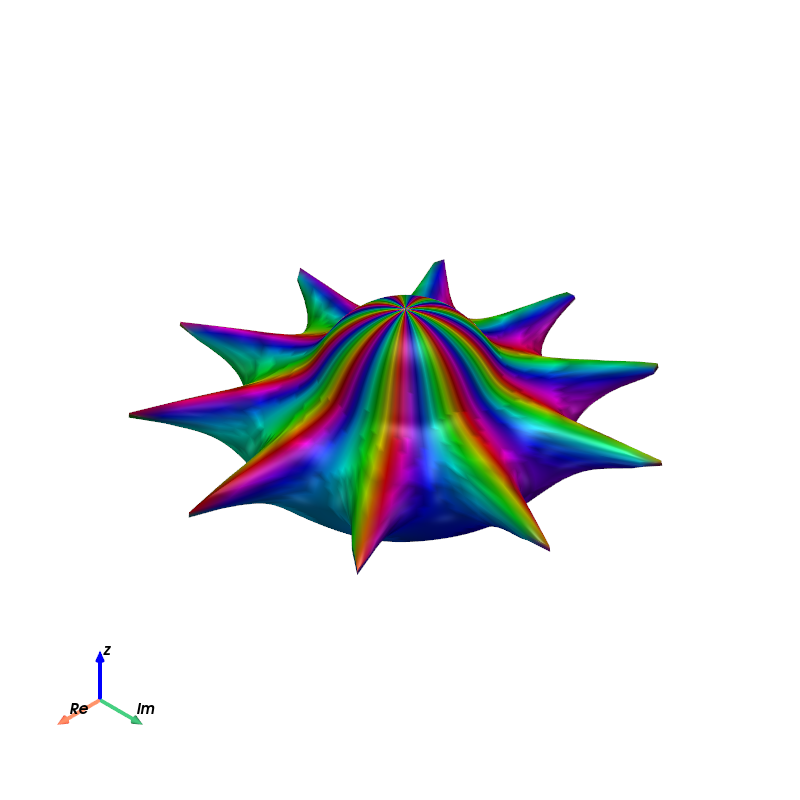


💡 Rotate and zoom to inspect the relief before exporting!
   Peaks = poles, Valleys = zeros


In [6]:
# Visualize the ornament in 3D before exporting
cp.riemann_pv(
    f,
    cmap=cp.Phase(phase_sectors=12, auto_scale_r=True),
    modulus_mode='arctan',  # Same scaling as ornament
    resolution=150,
    notebook=True
)

print("\n💡 Rotate and zoom to inspect the relief before exporting!")
print("   Peaks = poles, Valleys = zeros")

In [ ]:
# Create ornament generator
ornament = OrnamentGenerator(
    func=f,
    resolution=150,  # 150 for draft, 250+ for final
    scaling='arctan'  # Smooth topographic relief
)

# Generate and save STL file
ornament.generate_and_save('my_ornament.stl', size_mm=80)

print("\n✓ STL file exported: my_ornament.stl")
print("  Ready for slicing and 3D printing!")


✓ STL file exported: my_ornament.stl
  Ready for slicing and 3D printing!


## Customization: Scaling Methods

The example above used `scaling='arctan'` for smooth relief. Let's compare all available methods:

## Scaling Method Selection

In [ ]:
# Compare scaling methods
methods = ['constant', 'arctan', 'logarithmic']

for method in methods:
    orn = OrnamentGenerator(func=f, resolution=80, scaling=method)
    print(f"{method:12s}: {orn.scaling}")

print("\n💡 Recommendations:")
print("  • arctan: General use (smooth relief)")
print("  • logarithmic: Emphasize poles/zeros")
print("  • constant: Flat sphere (phase-only coloring)")

## 3D Printing Workflow (RECOMMENDED)

### Step 1: Bisect in Your Slicer

**Why bisect?** ✅ No supports needed ✅ Better quality ✅ Easier finishing ✅ Multi-color options

**In PrusaSlicer:**
1. Import `my_ornament.stl`
2. Right-click → **"Split to Parts"** (or use Cut tool with XY plane at Z=0)
3. This creates two hemispheres at the equator
4. **Flip one hemisphere**: Right-click → "Lay on Face" (so both rest on flat sides)
5. Export as `south_hemisphere.stl` and `north_hemisphere.stl`

**In Cura:**
1. Import STL → Right-click → Use "Per Model Settings" or plugins
2. Alternative: Use Meshmixer/Blender to split before importing
3. **Flip one hemisphere** so both lie flat on the build plate

### Step 2: Add Suspension (Optional)

**Ring/Hook for hanging:**
- In your slicer, import a ring/loop model
- Position it at the "north pole" of one hemisphere
- Merge/combine meshes before slicing
- Or drill a hole after printing and insert an eye screw

**Quick ring creation:**
- Use Tinkercad, Fusion 360, or OpenSCAD to create a simple loop
- Or find hanging hook models on Thingiverse/Printables

### Step 3: Print Both Hemispheres

**Settings:**
- Material: PLA (easiest), PETG, or ABS
- Layer height: 0.15-0.20mm
- Infill: 15-20% (ornaments don't need to be solid)
- **No supports needed!** (both pieces rest on flat equator)

**Tips:**
- Print both simultaneously if build plate allows
- Use same settings for both to ensure good fit

### Step 4: Glue Together

**Adhesives:**
- **PLA**: Cyanoacrylate (super glue) - fast and strong
- **PETG/ABS**: 2-part epoxy for stronger bond
- **ABS only**: Acetone welding (dissolves plastic for fusion)

**Procedure:**
1. **Clean surfaces**: Remove any stringing or imperfections from flat surfaces
2. **Dry fit**: Test alignment before applying glue
3. **Apply adhesive**: Thin, even layer on one equator surface
4. **Align**: Press hemispheres together, rotate slightly to spread glue
5. **Hold**: Clamp or hold for 1-5 minutes (check glue instructions)
6. **Cure**: Let sit 24 hours before handling or finishing

**Pro tips:**
- Wipe excess glue immediately with damp cloth
- Test on failed prints first
- For perfect alignment: Add small registration pins in slicer before printing

### Alternative: Single-Piece Print (Not Recommended)

You can print as one piece with supports, but:
- ❌ Requires extensive support structure
- ❌ Difficult support removal
- ❌ Lower quality on supported surfaces
- ✅ Only if you have excellent support removal skills

In [ ]:
# For functions with poles: exclude singularities
def pole_at_origin(z):
    return 1 / z

# BAD: includes pole
# bad_orn = OrnamentGenerator(func=pole_at_origin)

# GOOD: use annulus domain to exclude origin
domain_safe = cp.Annulus(inner_radius=0.1, outer_radius=10)
good_orn = OrnamentGenerator(
    func=pole_at_origin,
    domain=domain_safe,
    resolution=100
)

print("✓ Domain restriction ensures stable mesh generation")

## Slicer Bisection Workflow (RECOMMENDED)

### Why Bisect?

✅ **Better print quality** - no supports needed
✅ **Easier to print** - hemispheres lie flat on build plate
✅ **Multi-color** - paint or use different filaments
✅ **Post-processing** - easier to sand/finish flat surfaces

### How to Bisect in PrusaSlicer

1. **Import STL**: Load `my_ornament.stl`
2. **Split**: Right-click → "Split to Parts" (or use Cut tool)
3. **Cutting plane**: Select XY plane at Z=0 (equator)
4. **Export**: Save two hemispheres as separate STLs
   - `my_ornament_south.stl`
   - `my_ornament_north.stl`
5. **Print**: Each hemisphere separately (no supports!)

### How to Bisect in Cura

1. **Import STL**: Load the ornament
2. **Per Model Settings**: Right-click → "Per Model Settings" → "Mesh" (or use plugins)
3. **Alternative**: Use Meshmixer/Blender to split before importing

### Gluing Tips

**Adhesives**:
- PLA: Cyanoacrylate (super glue) works well
- PETG/ABS: Epoxy for stronger bond
- Optional: Solvent welding (acetone for ABS)

**Procedure**:
1. **Clean surfaces**: Remove any support remnants
2. **Dry fit**: Ensure hemispheres align perfectly
3. **Apply adhesive**: Thin, even layer on one surface
4. **Clamp**: Hold together 1-5 minutes (depends on glue)
5. **Cure**: Let sit 24 hours before handling

**Pro tips**:
- Add alignment pins: Small holes during design
- Magnetic assembly: Embed magnets in hemispheres
- Test piece: Print small version first

### Alternative: Single-Piece Print

Print as one piece with support:
- **Pros**: No gluing needed
- **Cons**: Requires supports, harder post-processing
- **Use case**: If you have good support removal skills

## Advanced Options

In [ ]:
# Resolution trade-offs
print("Resolution guide:")
print("  • 100: Fast preview (draft quality)")
print("  • 150: Good balance (default)")
print("  • 250: High quality")
print("  • 350+: Publication quality (slow, large file)")

# Size recommendations
print("\nSize guide:")
print("  • 60mm: Small desk ornament")
print("  • 80mm: Standard (default)")
print("  • 100mm: Large display piece")

# Colormap for painting reference
cmap_ref = cp.Phase(phase_sectors=12, auto_scale_r=True)
orn_colored = OrnamentGenerator(
    func=f,
    cmap=cmap_ref,  # Use for painting guide
    resolution=150
)
print("\n✓ Save colormap visualization as painting reference")

## Post-Processing & Finishing

### Sanding
1. Start: 200 grit
2. Progress: 400 → 600 → 800 grit
3. Optional: 1000+ for glass finish

### Painting
1. **Prime**: Spray primer (2-3 light coats)
2. **Base**: Acrylic paint (white or light gray)
3. **Details**: Use colormap visualization as guide
4. **Seal**: Clear coat (matte or gloss)

### Sealing
- Spray clear coat
- Or brush-on varnish
- Protects paint, adds shine

## Troubleshooting

**Non-manifold edges**
- Automatic repair in OrnamentGenerator
- Or use Meshmixer/netfabb

**Print failures**
- Check domain restrictions (exclude singularities)
- Reduce complexity (lower resolution)

**File too large**
- Reduce resolution
- Typical: 150 = ~1MB STL file

## Summary

✅ OrnamentGenerator workflow
✅ Scaling methods (arctan recommended)
✅ Domain restrictions for stability
✅ **Bisection workflow** (PrusaSlicer/Cura)
✅ Gluing tips and finishing
✅ Resolution and size guidelines

## See Also

- Example STL files in `examples/gallery/`
- [STL Export Guide](../../docs/user-guide/stl-export.md)

Transform math into physical art! 🎨🖨️